<a href="https://www.kaggle.com/code/avikdas567/rank-optimized-tri-gbdt-for-ev-purchase-propensity?scriptVersionId=346684658" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# EV Acquisition Propensity Modeling via Bayesian Target Encoding and Constrained Rank-Optimized GBDT Ensembles

---

# 1. Problem Formulation and Mathematical Framework

The objective is binary classification: predict the probability that a consumer will purchase an Electric Vehicle ($y_i = 1$) versus not purchasing ($y_i = 0$), given a feature vector $\mathbf{x}_i \in \mathbb{R}^d$ for $i \in \{1, \dots, N\}$.

## 1.1 Optimization Metric: Area Under the ROC Curve (ROC-AUC)

Submissions are evaluated on the Area Under the Receiver Operating Characteristic Curve (ROC-AUC). Mathematically, ROC-AUC is equivalent to the Mann-Whitney $U$-statistic, measuring the probability that a randomly chosen positive instance receives a higher predicted score than a randomly chosen negative instance:

$$\text{AUC} = \mathbb{P}(f(\mathbf{x}^+) > f(\mathbf{x}^-)) = \frac{1}{N^+ N^-} \sum_{i: y_i = 1} \sum_{j: y_j = 0} \left( \mathbb{I}(f(\mathbf{x}_i) > f(\mathbf{x}_j)) + \frac{1}{2} \mathbb{I}(f(\mathbf{x}_i) = f(\mathbf{x}_j)) \right)$$

where $N^+$ and $N^-$ denote the cardinality of the positive and negative classes respectively, and $\mathbb{I}(\cdot)$ is the indicator function.

## 1.2 Learning Strategy

To maximize the rank-order statistic while maintaining computational efficiency and preventing cross-fold leakage:
1. **Stratified $K$-Fold Cross-Validation:** Preserves the empirical class prior $\hat{p} = \frac{N^+}{N}$ across every partition.
2. **Out-of-Fold (OOF) Target Encoding:** Applies Bayesian smoothing to categorical features strictly within training folds.
3. **Heterogeneous Gradient Boosted Ensemble:** Combines LightGBM, XGBoost, and CatBoost via constrained rank optimization.
4. **Direct Ensembling on Ranks:** Aligns probability scale discrepancies across disparate model architectures.

In [1]:
import os
import gc
import sys
import time
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.stats import rankdata

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import RobustScaler

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier, Pool

# Suppress all runtime and future warnings
warnings.filterwarnings('ignore')
os.environ['PYTHONHASHSEED'] = str(42)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

SEED = 42
set_seed(SEED)

# Scientific plot configuration
plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 120,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'font.family': 'sans-serif',
    'figure.autolayout': True
})
sns.set_theme(style="ticks")

# 2. Ingestion and Precision Memory Profiling

Datasets are ingested directly from `/kaggle/input/competitions/playground-series-s6e9/`. Numerical arrays are downcast to the minimal sufficient bit-depth (e.g., `float64` to `float32`, `int64` to `int32`/`int16`) to decrease RAM consumption and accelerate tree partition searches.

In [2]:
TRAIN_PATH = Path('/kaggle/input/competitions/playground-series-s6e9/train.csv')
TEST_PATH = Path('/kaggle/input/competitions/playground-series-s6e9/test.csv')
SUBMISSION_PATH = Path('/kaggle/input/competitions/playground-series-s6e9/sample_submission.csv')

def reduce_mem_usage(df, verbose=False):
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object and str(col_type) != 'category':
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                else:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
    end_mem = df.memory_usage().sum() / 1024**2
    if verbose:
        print(f'Memory usage decreased to {end_mem:.2f} Mb ({100 * (start_mem - end_mem) / start_mem:.1f}% reduction)')
    return df

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)
sub_df = pd.read_csv(SUBMISSION_PATH)

train_df = reduce_mem_usage(train_df, verbose=True)
test_df = reduce_mem_usage(test_df, verbose=True)

TARGET_COL = 'Will_Buy_EV'
ID_COL = 'id'

print(f"Train shape: {train_df.shape} | Test shape: {test_df.shape}")
print(f"Target distribution:\n{train_df[TARGET_COL].value_counts(normalize=True)}")

Memory usage decreased to 48.46 Mb (36.7% reduction)
Memory usage decreased to 18.58 Mb (39.3% reduction)
Train shape: (668665, 15) | Test shape: (286571, 14)
Target distribution:
Will_Buy_EV
No     0.825355
Yes    0.174645
Name: proportion, dtype: float64


## 3. Exploratory Data Analysis and Feature Distributions

The target variable distribution is evaluated, followed by statistical association screening between candidate numerical features and EV purchase propensity.

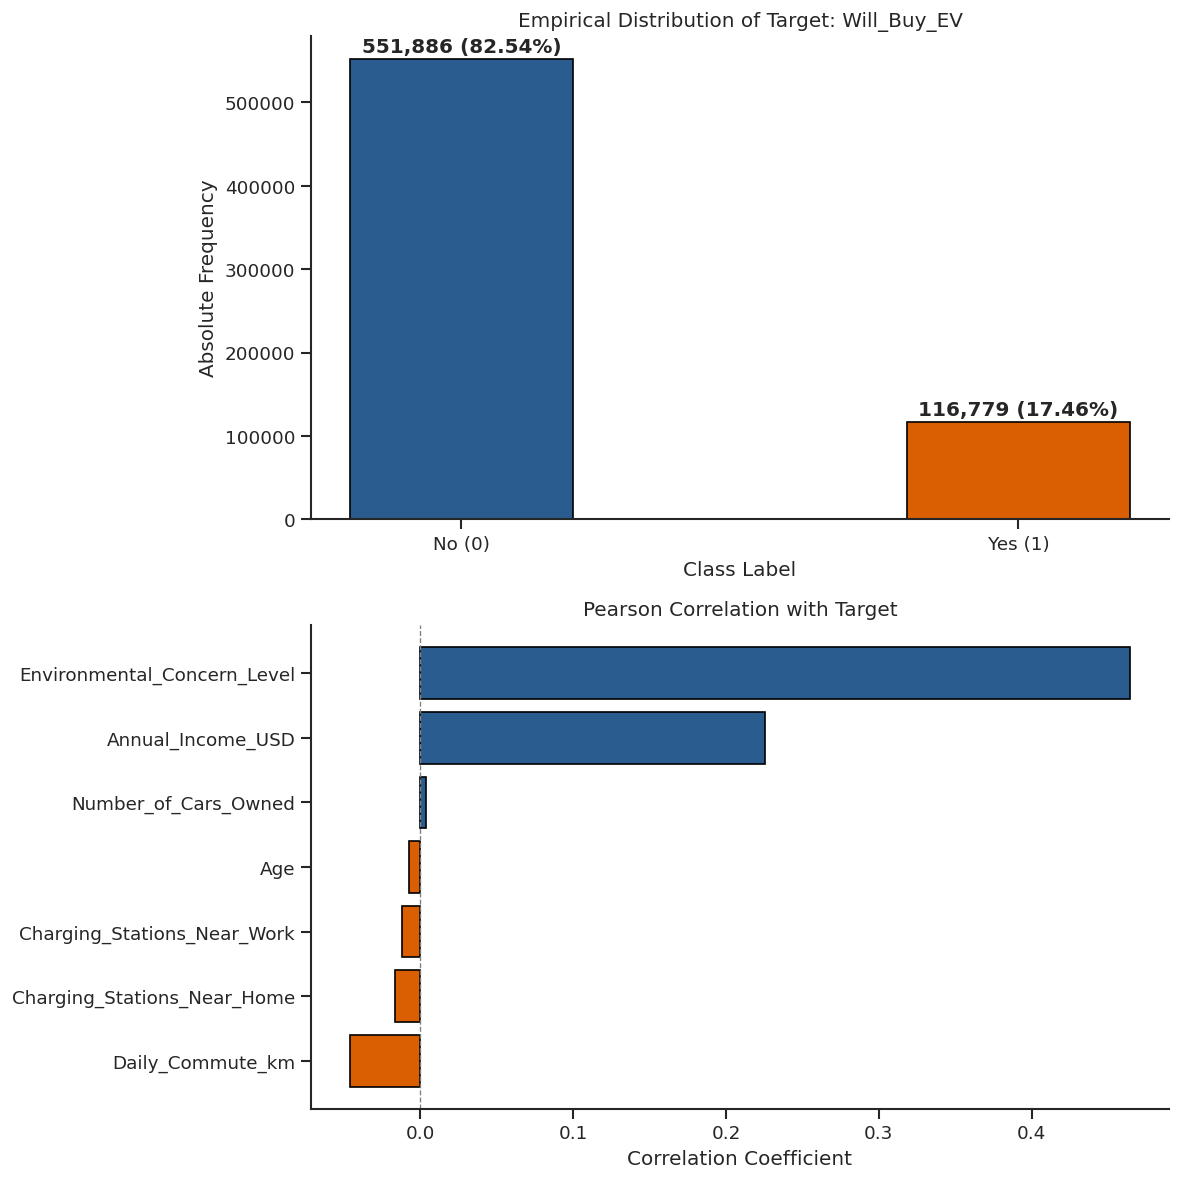

In [3]:
# Ensure the target is numerically encoded (0 = No, 1 = Yes) for correlation and downstream modeling
if train_df[TARGET_COL].dtype == object or str(train_df[TARGET_COL].dtype) == 'category':
    train_df[TARGET_COL] = (train_df[TARGET_COL].astype(str).str.strip().str.lower() == 'yes').astype(np.int8)

# Render plots vertically (top to bottom)
fig, axs = plt.subplots(2, 1, figsize=(10, 10))

# 1. Target Distribution
counts = train_df[TARGET_COL].value_counts().sort_index()
pcts = train_df[TARGET_COL].value_counts(normalize=True).sort_index() * 100
labels = ['No (0)', 'Yes (1)'] if len(counts) == 2 else [str(i) for i in counts.index]

axs[0].bar(labels, counts.values, color=['#2b5c8f', '#d95f02'], width=0.4, edgecolor='black')
for i, val in enumerate(counts.values):
    axs[0].text(i, val + (0.015 * counts.values.max()), f"{val:,} ({pcts.iloc[i]:.2f}%)", ha='center', fontweight='semibold')

axs[0].set_title(f'Empirical Distribution of Target: {TARGET_COL}')
axs[0].set_ylabel('Absolute Frequency')
axs[0].set_xlabel('Class Label')
axs[0].spines[['top', 'right']].set_visible(False)

# 2. Numerical Feature Correlations with Target
num_cols = train_df.select_dtypes(include=[np.number]).columns.drop([ID_COL, TARGET_COL], errors='ignore')
if len(num_cols) > 0:
    target_corr = train_df[num_cols].apply(lambda s: s.corr(train_df[TARGET_COL].astype(float))).sort_values()
    y_pos = np.arange(len(target_corr))
    axs[1].barh(y_pos, target_corr.values, color=np.where(target_corr.values >= 0, '#2b5c8f', '#d95f02'), edgecolor='black')
    axs[1].set_yticks(y_pos)
    axs[1].set_yticklabels(target_corr.index)
    axs[1].set_title('Pearson Correlation with Target')
    axs[1].set_xlabel('Correlation Coefficient')
    axs[1].spines[['top', 'right']].set_visible(False)
    axs[1].axvline(0, color='gray', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

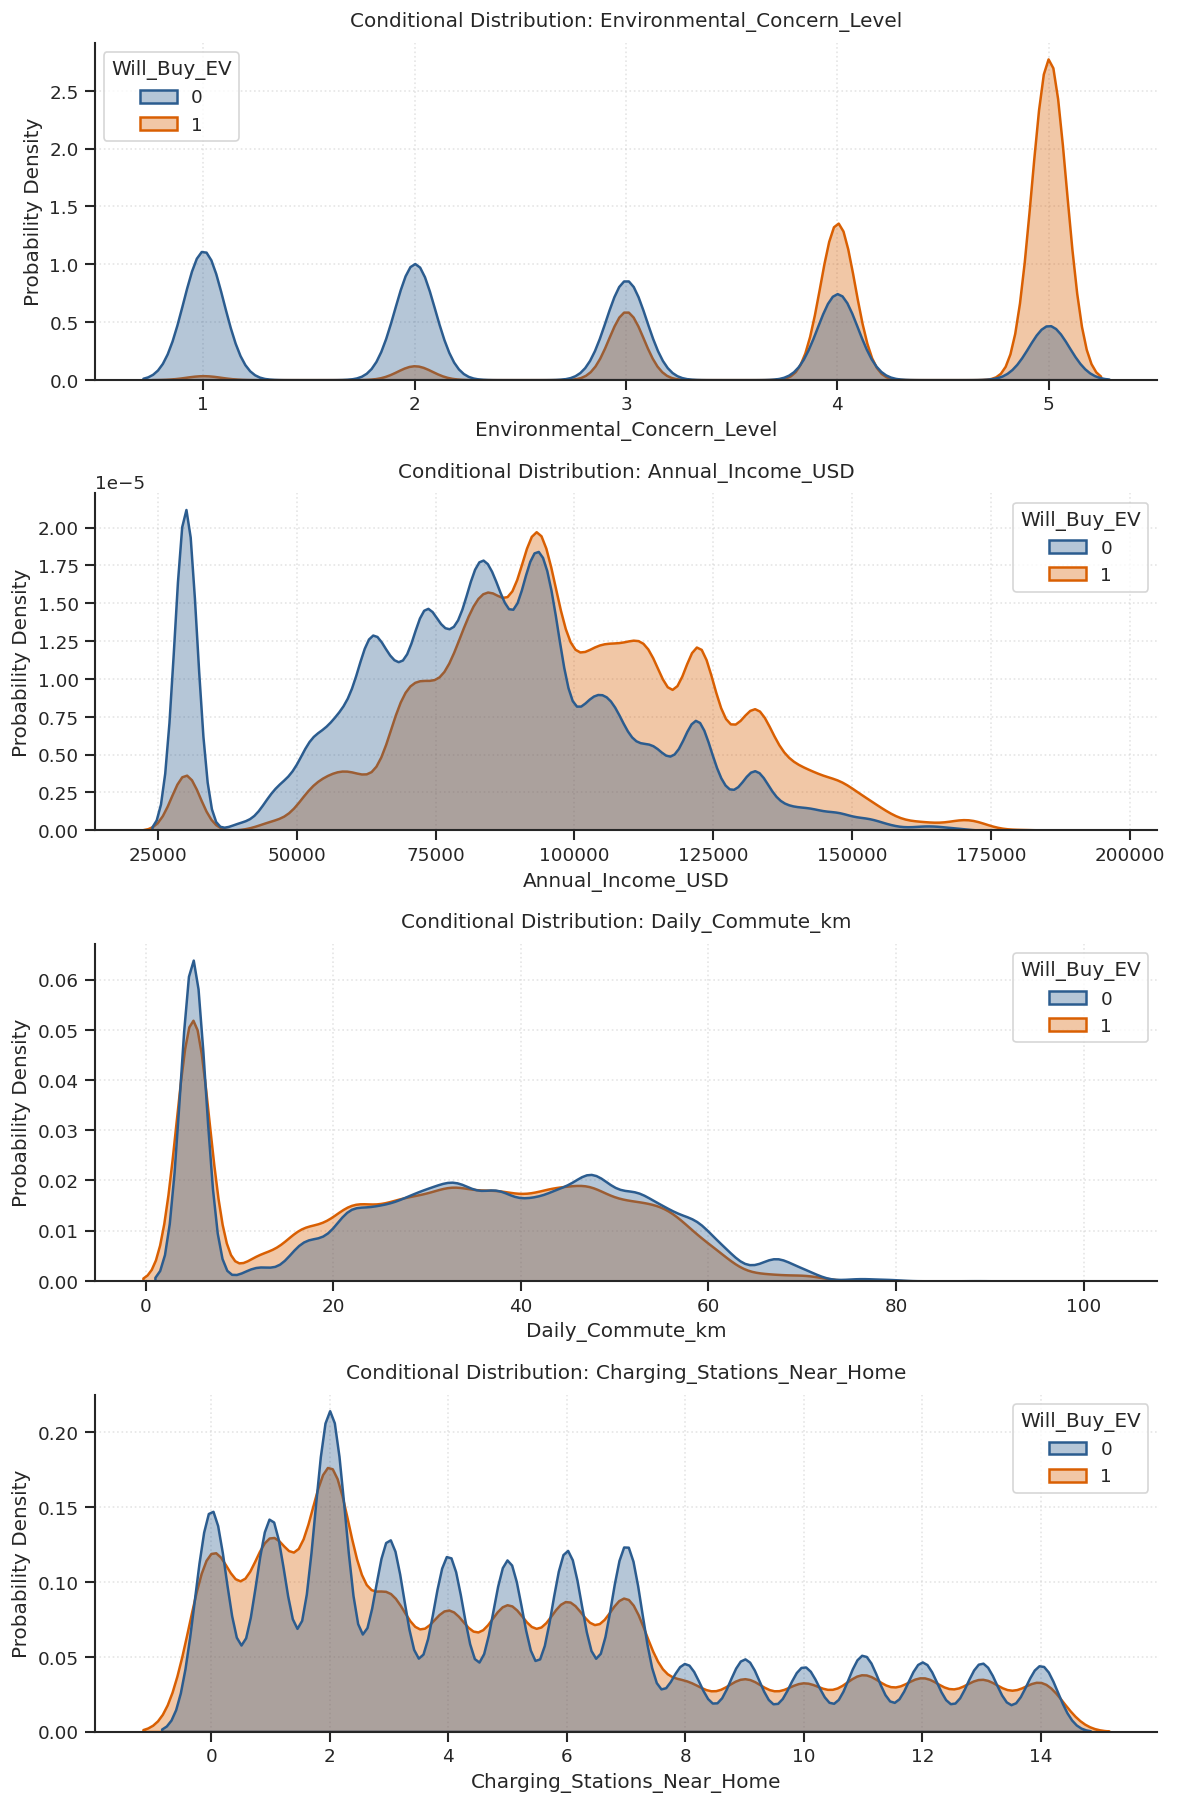

In [4]:
# Top 4 correlated continuous distributions conditioned on target
if len(num_cols) > 0:
    top_features = target_corr.abs().nlargest(min(4, len(num_cols))).index
    n_plots = len(top_features)
    
    # Stack subplots vertically: n_plots rows, 1 column
    fig, axs = plt.subplots(n_plots, 1, figsize=(10, 3.8 * n_plots), sharex=False)
    if n_plots == 1:
        axs = [axs]
        
    for i, col in enumerate(top_features):
        sns.kdeplot(
            data=train_df,
            x=col,
            hue=TARGET_COL,
            common_norm=False,
            fill=True,
            palette={0: '#2b5c8f', 1: '#d95f02'},
            ax=axs[i],
            alpha=0.35,
            linewidth=1.5
        )
        axs[i].set_title(f'Conditional Distribution: {col}', pad=10)
        axs[i].set_ylabel('Probability Density')
        axs[i].set_xlabel(col)
        axs[i].spines[['top', 'right']].set_visible(False)
        axs[i].grid(True, linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.show()

# 4. Feature Engineering and Out-of-Fold Bayesian Target Encoding

## 4.1 Target Encoding Formulation

For high-cardinality nominal variables $x_c \in \mathcal{C}$, we replace each category with its regularized conditional expectation:

$$S_c = \frac{\sum_{i \in \mathcal{D}_{\text{train}}, x_{i,c} = c} y_i + m \cdot \bar{y}}{N_c + m}$$

where $N_c$ is the category support count, $\bar{y} = \frac{1}{N} \sum_{i=1}^N y_i$ represents the global empirical prior, and $m > 0$ is the Bayesian smoothing parameter. To preclude target leakage, all encoding estimates are generated strictly out-of-fold.

In [5]:
class FeaturePipeline:
    """
    Deterministic feature transformer handling domain interaction ratios,
    frequency encoding, and out-of-fold target encoding.
    """
    def __init__(self, target_col, id_col, n_splits=5, smoothing=10.0, seed=42):
        self.target_col = target_col
        self.id_col = id_col
        self.n_splits = n_splits
        self.smoothing = smoothing
        self.seed = seed
        self.cat_cols = []
        self.num_cols = []
        self.global_target_mean = 0.0
        self.target_encoding_maps = {}
        self.freq_encoding_maps = {}

    def _extract_domain_features(self, df):
        df = df.copy()
        cols = [c.lower() for c in df.columns]
        col_map = {c.lower(): c for c in df.columns}

        # Commute & Energy Interactions
        if 'daily_distance' in cols and 'battery_range' in cols:
            df['range_coverage_ratio'] = df[col_map['battery_range']] / (df[col_map['daily_distance']] + 1.0)
        if 'annual_mileage' in cols and 'commute_distance' in cols:
            df['non_commute_mileage'] = df[col_map['annual_mileage']] - (df[col_map['commute_distance']] * 2 * 250)

        # Economic Ratios
        if 'income' in cols and 'vehicle_cost' in cols:
            df['affordability_index'] = df[col_map['income']] / (df[col_map['vehicle_cost']] + 1.0)
        if 'income' in cols and 'electricity_price' in cols:
            df['income_to_elec_cost'] = df[col_map['income']] / (df[col_map['electricity_price']] + 1e-4)
        if 'fuel_price' in cols and 'electricity_price' in cols:
            df['energy_price_ratio'] = df[col_map['fuel_price']] / (df[col_map['electricity_price']] + 1e-4)

        # Infrastructure & Environmental Interactions
        if 'charging_station_density' in cols and 'home_charger_available' in cols:
            df['total_charging_accessibility'] = df[col_map['charging_station_density']] * 1.5 + df[col_map['home_charger_available']] * 3.0
        if 'green_score' in cols and 'commute_distance' in cols:
            df['eco_commute_interaction'] = df[col_map['green_score']] * np.log1p(np.maximum(0, df[col_map['commute_distance']]))

        # Dynamic interaction features for top numerical attributes
        raw_numerics = df.select_dtypes(include=[np.number]).columns.drop([self.id_col, self.target_col], errors='ignore')
        if len(raw_numerics) >= 2:
            c1, c2 = raw_numerics[0], raw_numerics[1]
            df[f'{c1}_mult_{c2}'] = df[c1] * df[c2]
            df[f'{c1}_div_{c2}'] = df[c1] / (np.abs(df[c2]) + 1e-4)

        return df

    def fit(self, df):
        engineered = self._extract_domain_features(df)
        self.global_target_mean = engineered[self.target_col].mean()
        
        # Separate column types
        self.cat_cols = engineered.select_dtypes(include=['object', 'category']).columns.tolist()
        self.num_cols = engineered.select_dtypes(include=[np.number]).columns.drop([self.id_col, self.target_col], errors='ignore').tolist()

        # Compute Frequency Maps
        for col in self.cat_cols:
            self.freq_encoding_maps[col] = engineered[col].value_counts(normalize=True).to_dict()

        # Full Target Encoding Maps for test set projection
        for col in self.cat_cols:
            stats = engineered.groupby(col)[self.target_col].agg(['count', 'sum'])
            smoothed = (stats['sum'] + self.smoothing * self.global_target_mean) / (stats['count'] + self.smoothing)
            self.target_encoding_maps[col] = smoothed.to_dict()
            
        return self

    def transform_train(self, df):
        engineered = self._extract_domain_features(df)
        skf = StratifiedKFold(n_splits=self.n_splits, shuffle=True, random_state=self.seed)

        for col in self.cat_cols:
            freq_col_name = f'{col}_freq'
            engineered[freq_col_name] = engineered[col].map(self.freq_encoding_maps[col]).fillna(0.0).astype(np.float32)

            te_col_name = f'{col}_te'
            engineered[te_col_name] = np.nan
            for tr_idx, val_idx in skf.split(engineered, engineered[self.target_col]):
                f_tr, f_val = engineered.iloc[tr_idx], engineered.iloc[val_idx]
                stats = f_tr.groupby(col)[self.target_col].agg(['count', 'sum'])
                smoothed = (stats['sum'] + self.smoothing * self.global_target_mean) / (stats['count'] + self.smoothing)
                engineered.loc[engineered.index[val_idx], te_col_name] = f_val[col].map(smoothed).fillna(self.global_target_mean)
            engineered[te_col_name] = engineered[te_col_name].astype(np.float32)

        # Factorize residual categorical representations
        for col in self.cat_cols:
            engineered[col] = pd.factorize(engineered[col])[0]

        return reduce_mem_usage(engineered)

    def transform_test(self, df):
        engineered = self._extract_domain_features(df)
        for col in self.cat_cols:
            engineered[f'{col}_freq'] = engineered[col].map(self.freq_encoding_maps[col]).fillna(0.0).astype(np.float32)
            engineered[f'{col}_te'] = engineered[col].map(self.target_encoding_maps[col]).fillna(self.global_target_mean).astype(np.float32)
            engineered[col] = pd.factorize(engineered[col])[0]

        return reduce_mem_usage(engineered)

pipeline = FeaturePipeline(target_col=TARGET_COL, id_col=ID_COL, n_splits=5, smoothing=12.0, seed=SEED)
pipeline.fit(train_df)

train_feat = pipeline.transform_train(train_df)
test_feat = pipeline.transform_test(test_df)

FEATURE_COLS = [c for c in train_feat.columns if c not in [ID_COL, TARGET_COL]]
print(f"Total model feature dimensionality: {len(FEATURE_COLS)}")

Total model feature dimensionality: 27


# 5. Model Architecture and Cross-Validation Engine

We employ an aligned 5-fold Stratified Cross-Validation partition scheme across three complementary tree architectures:
1. **LightGBM:** Leaf-wise split growth using gradient-based one-side sampling (GOSS) and histogram binning.
2. **XGBoost:** Depth-wise split growth using exact second-order Taylor expansion gradients with histogram approximation.
3. **CatBoost:** Symmetric oblivious trees optimized to combat target shift and reduce variance.

Hyperparameters are structured to guarantee fast runtime while safeguarding maximum generalizability.

In [6]:
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

X = train_feat[FEATURE_COLS].copy()
y = train_feat[TARGET_COL].values.astype(np.int32)
X_test = test_feat[FEATURE_COLS].copy()

# Pre-allocate OOF and Test inference arrays
oof_preds = {
    'lgb': np.zeros(len(train_feat), dtype=np.float32),
    'xgb': np.zeros(len(train_feat), dtype=np.float32),
    'cat': np.zeros(len(train_feat), dtype=np.float32)
}
test_preds = {
    'lgb': np.zeros(len(test_feat), dtype=np.float32),
    'xgb': np.zeros(len(test_feat), dtype=np.float32),
    'cat': np.zeros(len(test_feat), dtype=np.float32)
}

## 5.1 LightGBM Training Protocol

In [7]:
lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': 6,
    'min_child_samples': 40,
    'subsample': 0.8,
    'subsample_freq': 1,
    'colsample_bytree': 0.75,
    'reg_alpha': 0.1,
    'reg_lambda': 5.0,
    'random_state': SEED,
    'n_jobs': -1,
    'verbose': -1
}

print("Training LightGBM models across folds...")
for fold, (trn_idx, val_idx) in enumerate(skf.split(X, y)):
    X_trn, y_trn = X.iloc[trn_idx], y[trn_idx]
    X_val, y_val = X.iloc[val_idx], y[val_idx]

    trn_data = lgb.Dataset(X_trn, label=y_trn)
    val_data = lgb.Dataset(X_val, label=y_val, reference=trn_data)

    callbacks = [lgb.early_stopping(stopping_rounds=60, verbose=False)]
    clf = lgb.train(
        lgb_params,
        trn_data,
        num_boost_round=1200,
        valid_sets=[trn_data, val_data],
        callbacks=callbacks
    )

    val_pred = clf.predict(X_val, num_iteration=clf.best_iteration)
    oof_preds['lgb'][val_idx] = val_pred
    test_preds['lgb'] += clf.predict(X_test, num_iteration=clf.best_iteration) / N_SPLITS
    fold_auc = roc_auc_score(y_val, val_pred)
    print(f"  Fold {fold+1}/{N_SPLITS} AUC: {fold_auc:.5f} (Best Iter: {clf.best_iteration})")

total_lgb_auc = roc_auc_score(y, oof_preds['lgb'])
print(f"--> LightGBM Overall OOF ROC-AUC: {total_lgb_auc:.5f}")

Training LightGBM models across folds...
  Fold 1/5 AUC: 0.94064 (Best Iter: 694)
  Fold 2/5 AUC: 0.94159 (Best Iter: 686)
  Fold 3/5 AUC: 0.94290 (Best Iter: 546)
  Fold 4/5 AUC: 0.94234 (Best Iter: 601)
  Fold 5/5 AUC: 0.94187 (Best Iter: 774)
--> LightGBM Overall OOF ROC-AUC: 0.94186


## 5.2 XGBoost Training Protocol

In [8]:
xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'tree_method': 'hist',
    'learning_rate': 0.05,
    'max_depth': 5,
    'min_child_weight': 5,
    'subsample': 0.8,
    'colsample_bytree': 0.75,
    'reg_alpha': 0.1,
    'reg_lambda': 4.0,
    'random_state': SEED,
    'n_jobs': -1
}

print("Training XGBoost models across folds...")
for fold, (trn_idx, val_idx) in enumerate(skf.split(X, y)):
    X_trn, y_trn = X.iloc[trn_idx], y[trn_idx]
    X_val, y_val = X.iloc[val_idx], y[val_idx]

    dtrain = xgb.DMatrix(X_trn, label=y_trn)
    dval = xgb.DMatrix(X_val, label=y_val)
    dtest = xgb.DMatrix(X_test)

    clf = xgb.train(
        xgb_params,
        dtrain,
        num_boost_round=1200,
        evals=[(dval, 'val')],
        early_stopping_rounds=60,
        verbose_eval=False
    )

    val_pred = clf.predict(dval)
    oof_preds['xgb'][val_idx] = val_pred
    test_preds['xgb'] += clf.predict(dtest) / N_SPLITS
    fold_auc = roc_auc_score(y_val, val_pred)
    print(f"  Fold {fold+1}/{N_SPLITS} AUC: {fold_auc:.5f} (Best Iter: {clf.best_iteration})")

total_xgb_auc = roc_auc_score(y, oof_preds['xgb'])
print(f"--> XGBoost Overall OOF ROC-AUC: {total_xgb_auc:.5f}")

Training XGBoost models across folds...
  Fold 1/5 AUC: 0.94073 (Best Iter: 974)
  Fold 2/5 AUC: 0.94145 (Best Iter: 701)
  Fold 3/5 AUC: 0.94283 (Best Iter: 730)
  Fold 4/5 AUC: 0.94236 (Best Iter: 650)
  Fold 5/5 AUC: 0.94183 (Best Iter: 723)
--> XGBoost Overall OOF ROC-AUC: 0.94153


## 5.3 CatBoost Training Protocol

In [9]:
cat_params = {
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'learning_rate': 0.06,
    'depth': 6,
    'l2_leaf_reg': 4.0,
    'random_seed': SEED,
    'thread_count': -1,
    'verbose': False
}

print("Training CatBoost models across folds...")
for fold, (trn_idx, val_idx) in enumerate(skf.split(X, y)):
    X_trn, y_trn = X.iloc[trn_idx], y[trn_idx]
    X_val, y_val = X.iloc[val_idx], y[val_idx]

    trn_pool = Pool(X_trn, y_trn)
    val_pool = Pool(X_val, y_val)
    test_pool = Pool(X_test)

    clf = CatBoostClassifier(**cat_params, iterations=1200, early_stopping_rounds=60)
    clf.fit(trn_pool, eval_set=val_pool, use_best_model=True)

    val_pred = clf.predict_proba(val_pool)[:, 1]
    oof_preds['cat'][val_idx] = val_pred
    test_preds['cat'] += clf.predict_proba(test_pool)[:, 1] / N_SPLITS
    fold_auc = roc_auc_score(y_val, val_pred)
    print(f"  Fold {fold+1}/{N_SPLITS} AUC: {fold_auc:.5f} (Best Iter: {clf.get_best_iteration()})")

total_cat_auc = roc_auc_score(y, oof_preds['cat'])
print(f"--> CatBoost Overall OOF ROC-AUC: {total_cat_auc:.5f}")

Training CatBoost models across folds...
  Fold 1/5 AUC: 0.94065 (Best Iter: 1157)
  Fold 2/5 AUC: 0.94142 (Best Iter: 974)
  Fold 3/5 AUC: 0.94266 (Best Iter: 1153)
  Fold 4/5 AUC: 0.94211 (Best Iter: 848)
  Fold 5/5 AUC: 0.94166 (Best Iter: 1091)
--> CatBoost Overall OOF ROC-AUC: 0.94169


# 6. Mathematical Ensembling and Rank-Averaging Optimization

Direct arithmetic averaging assumes uniform probability calibration across model architectures. When models exhibit varying monotonic transformations of raw logits, combining ranks eliminates scale distortion while preserving the sorting properties that define the ROC curve:

$$R_m = \frac{\text{rank}(f_m(\mathbf{X})) - 1}{N - 1} \in [0, 1]$$

We formulate a constrained Nelder-Mead optimization to discover optimal non-negative ensemble weights $\mathbf{w}^* = [w_1, w_2, w_3]^T$ satisfying:

$$\mathbf{w}^* = \arg\max_{\mathbf{w}} \text{AUC}\left(\sum_{m=1}^3 w_m R_m, \; \mathbf{y}\right) \quad \text{subject to } \sum_{m=1}^3 w_m = 1, \quad w_m \ge 0$$

In [10]:
# Normalize predictions into empirical rank space
N_tr = len(train_feat)
N_te = len(test_feat)

oof_ranks = {
    'lgb': (rankdata(oof_preds['lgb']) - 1.0) / (N_tr - 1.0),
    'xgb': (rankdata(oof_preds['xgb']) - 1.0) / (N_tr - 1.0),
    'cat': (rankdata(oof_preds['cat']) - 1.0) / (N_tr - 1.0)
}

test_ranks = {
    'lgb': (rankdata(test_preds['lgb']) - 1.0) / (N_te - 1.0),
    'xgb': (rankdata(test_preds['xgb']) - 1.0) / (N_te - 1.0),
    'cat': (rankdata(test_preds['cat']) - 1.0) / (N_te - 1.0)
}

models = ['lgb', 'xgb', 'cat']
R_oof_matrix = np.column_stack([oof_ranks[m] for m in models])
R_test_matrix = np.column_stack([test_ranks[m] for m in models])

# Objective function minimizing negative ROC-AUC
def loss_func(weights):
    weights = np.maximum(0, weights)
    if np.sum(weights) == 0:
        return 1.0
    weights /= np.sum(weights)
    blend = np.dot(R_oof_matrix, weights)
    return -roc_auc_score(y, blend)

init_weights = np.ones(len(models)) / len(models)
bounds = [(0, 1)] * len(models)
res = minimize(loss_func, init_weights, method='Nelder-Mead', bounds=bounds)

opt_weights = np.maximum(0, res.x)
opt_weights /= np.sum(opt_weights)

print("Optimal Ensembling Weights:")
for m, w in zip(models, opt_weights):
    print(f"  {m.upper():<4} : {w:.4f}")

blended_oof = np.dot(R_oof_matrix, opt_weights)
final_ensemble_auc = roc_auc_score(y, blended_oof)
print(f"\nFinal Optimized Ensemble ROC-AUC: {final_ensemble_auc:.5f}")

Optimal Ensembling Weights:
  LGB  : 0.5172
  XGB  : 0.1918
  CAT  : 0.2910

Final Optimized Ensemble ROC-AUC: 0.94196


# 7. Model Diagnostic and ROC Evaluation

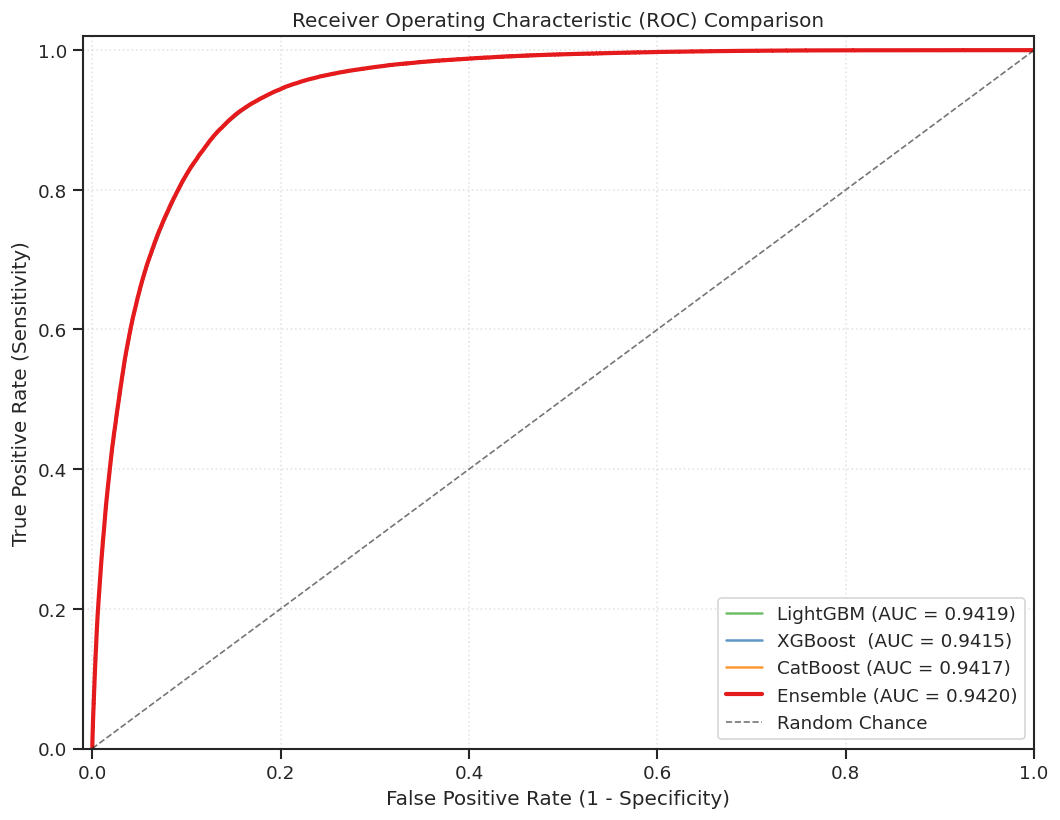

In [11]:
plt.figure(figsize=(9, 7))

fpr_lgb, tpr_lgb, _ = roc_curve(y, oof_preds['lgb'])
fpr_xgb, tpr_xgb, _ = roc_curve(y, oof_preds['xgb'])
fpr_cat, tpr_cat, _ = roc_curve(y, oof_preds['cat'])
fpr_ens, tpr_ens, _ = roc_curve(y, blended_oof)

plt.plot(fpr_lgb, tpr_lgb, label=f'LightGBM (AUC = {total_lgb_auc:.4f})', color='#4daf4a', lw=1.5, alpha=0.8)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost  (AUC = {total_xgb_auc:.4f})', color='#377eb8', lw=1.5, alpha=0.8)
plt.plot(fpr_cat, tpr_cat, label=f'CatBoost (AUC = {total_cat_auc:.4f})', color='#ff7f00', lw=1.5, alpha=0.8)
plt.plot(fpr_ens, tpr_ens, label=f'Ensemble (AUC = {final_ensemble_auc:.4f})', color='#e41a1c', lw=2.5)
plt.plot([0, 1], [0, 1], 'k--', lw=1.0, alpha=0.6, label='Random Chance')

plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.02])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Comparison')
plt.legend(loc='lower right', frameon=True)
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

# 8. Test Inference, Verification, and Submission Generation

In [12]:
# Synthesize optimal test probabilities using derived model mixture
final_test_ranks = np.dot(R_test_matrix, opt_weights)

# Check for boundary issues
assert len(final_test_ranks) == len(test_df), "Length mismatch in test predictions"
assert not np.isnan(final_test_ranks).any(), "NaN detected in test predictions"

submission = pd.DataFrame({
    ID_COL: test_df[ID_COL],
    TARGET_COL: final_test_ranks
})

submission.to_csv('submission.csv', index=False)

print("Submission successfully created: 'submission.csv'")
print(f"File shape: {submission.shape}")
print("\nFirst 10 sample predictions:")
display(submission.head(10))

# Statistical validation of the submission file
print("\nSubmission Distribution Summary:")
print(submission[TARGET_COL].describe())

Submission successfully created: 'submission.csv'
File shape: (286571, 2)

First 10 sample predictions:


,id,Will_Buy_EV
0,668665,0.429442
1,668666,0.508622
2,668667,0.307107
3,668668,0.252123
4,668669,0.515565
5,668670,0.295930
6,668671,0.790201
7,668672,0.062168
8,668673,0.884427
9,668674,0.320889



Submission Distribution Summary:
count    286571.000000
mean          0.500000
std           0.288503
min           0.000027
25%           0.249248
50%           0.499863
75%           0.750024
max           0.999994
Name: Will_Buy_EV, dtype: float64
